In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

In [2]:
df = pd.read_excel("ENB2012_data.xlsx")

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
# Drop unnamed column if exists
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Features and Target
X = df.drop(columns=['Y1', 'Y2'])

# Convert regression target → classification (binary)
y = (df['Y1'] > df['Y1'].median()).astype(int)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [5]:
print("\nRANDOM FOREST GRID SEARCH")
print(f"\nBest Parameters: {rf_grid_search.best_params_}")
print(f"Best CV Score (F1): {rf_grid_search.best_score_:.4f}")

best_rf = rf_grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("\nBEST RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'High']))


RANDOM FOREST GRID SEARCH

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score (F1): 0.9902

BEST RANDOM FOREST
Accuracy: 0.9870

Confusion Matrix:
[[77  0]
 [ 2 75]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.97      1.00      0.99        77
        High       1.00      0.97      0.99        77

    accuracy                           0.99       154
   macro avg       0.99      0.99      0.99       154
weighted avg       0.99      0.99      0.99       154



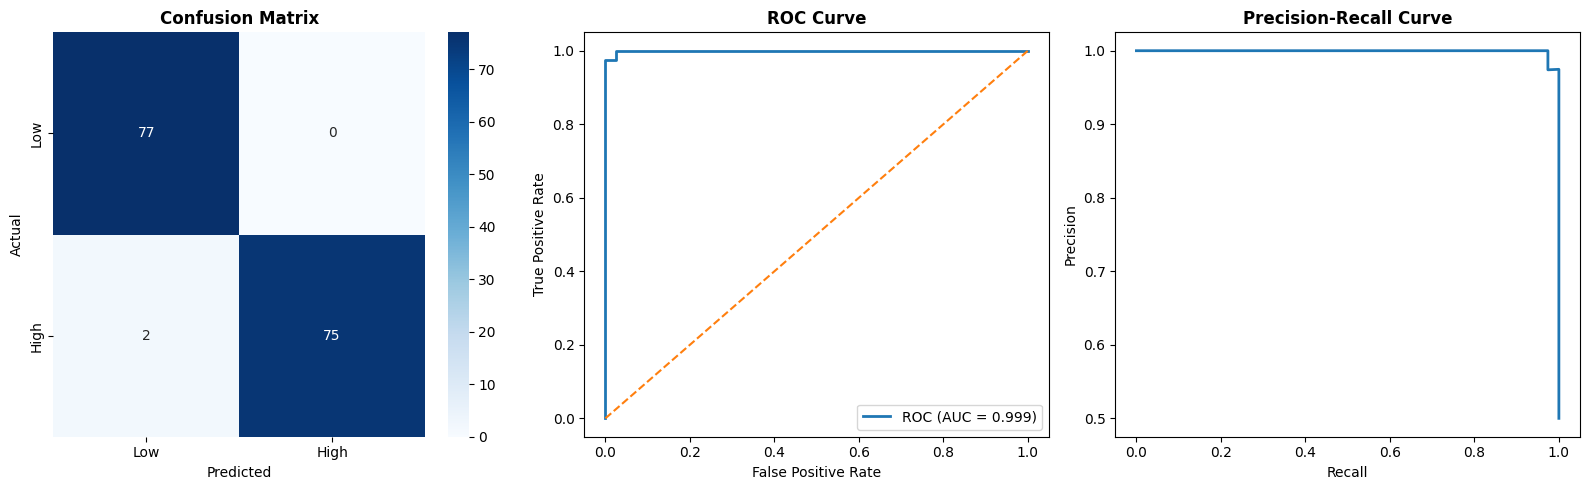

In [6]:
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])

axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(fpr_rf, tpr_rf, lw=2, label=f'ROC (AUC = {roc_auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# Precision-Recall Curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)

axes[2].plot(recall_rf, precision_rf, lw=2)
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.tight_layout()
plt.savefig('random_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()

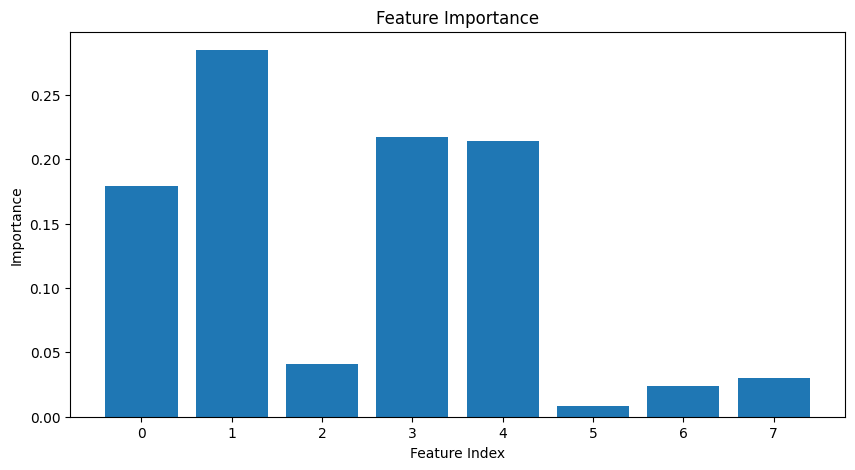

In [7]:
importances = best_rf.feature_importances_

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()